# Ejercicio 5 - Incorporacion de datos de 2024

## Configuracion

In [1]:
import os
import subprocess
import sys
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "scripts"))

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

con = duckdb.connect()   # base en memoria: todo se lee directo de los Parquet


def q(sql):
    inicio = time.perf_counter()
    df = con.sql(sql).df()
    print(f"{len(df)} filas | {time.perf_counter() - inicio:.2f} s")
    return df


print("DuckDB", con.sql("SELECT version()").fetchone()[0])

DuckDB v1.5.5


## 5.1 Cambio en el sistema de descarga

In [2]:
import download_data

print("Anios por defecto del script:", download_data.ANIOS_POR_DEFECTO)
print()
lineas = Path("scripts/download_data.py").read_text(encoding="utf-8").splitlines()
inicio = next(i for i, l in enumerate(lineas) if l.startswith("ANIOS_POR_DEFECTO"))
print("\n".join(lineas[inicio - 2: inicio + 1]))

Anios por defecto del script: (2024, 2026)

# Anios que forman el conjunto de datos del laboratorio. Para incorporar un
# anio nuevo basta con agregarlo aqui: los archivos ya descargados se omiten.
ANIOS_POR_DEFECTO = (2024, 2026)


## 5.2 a 5.4 Ejecucion del proceso de descarga

In [3]:
inicio = time.perf_counter()
proceso = subprocess.run([sys.executable, "scripts/download_data.py"], capture_output=True, text=True)
salida = proceso.stdout.splitlines()
print(f"Codigo de salida: {proceso.returncode} | {time.perf_counter() - inicio:.1f} s\n")

conteo = pd.Series({
    "descargados en esta ejecucion": sum("listo (" in l for l in salida),
    "ya existian y se omitieron": sum("se omite" in l for l in salida),
    "aun no publicados": sum("aun no publicado" in l for l in salida),
})
display(conteo.to_frame("meses"))
print("\n".join(salida[salida.index("RESUMEN") - 1:]))

Codigo de salida: 0 | 20.2 s



,meses
descargados en esta ejecucion,0
ya existian y se omitieron,40
aun no publicados,8


RESUMEN
  anios         : 2024, 2026
  descargados   : 0
  ya existian   : 40
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0
  manifiesto    : data/raw/manifest.csv


## 5.5 Verificacion de los archivos incorporados

In [4]:
q('''
SELECT anio, tipo, estado, count(*) AS meses,
       round(sum(bytes_local) / 1024 / 1024, 1) AS mib_locales,
       bool_and(bytes_local = bytes_servidor) FILTER (estado <> 'no_publicado') AS tamanios_coinciden
FROM read_csv('data/raw/manifest.csv')
GROUP BY ALL
ORDER BY anio, tipo DESC, estado
''')

6 filas | 0.02 s


,anio,tipo,estado,meses,mib_locales,tamanios_coinciden
0,2024,yellow,completo,12,660.90,True
1,2024,green,completo,12,15.20,True
2,2026,yellow,completo,8,487.80,True
3,2026,yellow,no_publicado,4,NaN,<NA>
4,2026,green,completo,8,7.90,True
5,2026,green,no_publicado,4,NaN,<NA>


In [5]:
q('''
SELECT split_part(file_name, '/', 4)                                      AS anio,
       split_part(file_name, '/', 3)                                      AS tipo,
       count(*)                                                           AS archivos,
       min(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet$', 1))       AS primer_mes,
       max(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet$', 1))       AS ultimo_mes,
       sum(num_rows)                                                      AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY anio, tipo DESC
''')

4 filas | 0.01 s


,anio,tipo,archivos,primer_mes,ultimo_mes,registros
0,2024,yellow,12,2024-01,2024-12,"41,169,720.00"
1,2024,green,12,2024-01,2024-12,"660,218.00"
2,2026,yellow,8,2026-01,2026-08,"29,703,355.00"
3,2026,green,8,2026-01,2026-08,"337,114.00"


## 5.6 Consulta conjunta de 2024 y 2026

In [6]:
q('''
SELECT coalesce(split_part(filename, '/', 4), 'TOTAL')   AS anio,
       count(*) FILTER (filename LIKE '%/yellow/%')      AS yellow,
       count(*) FILTER (filename LIKE '%/green/%')       AS green,
       count(*)                                          AS total
FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
GROUP BY ROLLUP (split_part(filename, '/', 4))
ORDER BY anio
''')

3 filas | 0.76 s


,anio,yellow,green,total
0,2024,41169720,660218,41829938
1,2026,29703355,337114,30040469
2,TOTAL,70873075,997332,71870407


40 filas | 1.25 s


tipo     yellow                                    green                              
anio       2024       2026 cambio % 2024 a 2026     2024     2026 cambio % 2024 a 2026
mes                                                                                   
1     95,632.00 120,157.00                25.65 1,824.00 1,298.00               -28.84
2    103,707.00 121,423.00                17.08 1,847.00 1,334.00               -27.77
3    115,568.00 127,498.00                10.32 1,853.00 1,426.00               -23.04
4    117,143.00 127,708.00                 9.02 1,882.00 1,475.00               -21.63
5    120,123.00 131,962.00                 9.86 1,968.00 1,449.00               -26.37
6    117,971.00 127,908.00                 8.42 1,825.00 1,472.00               -19.34
7     99,253.00 113,873.00                14.73 1,671.00 1,330.00               -20.41
8     96,101.00 107,636.00                12.00 1,669.00 1,312.00               -21.39
9    121,099.00        NaN                  NaN 1,814.00      NaN                  NaN
10   123,669.00        NaN                  NaN 1,811.00      NaN                  NaN
11   121,544.00        NaN                  NaN 1,740.00      NaN                  NaN
12   118,333.00        NaN                  NaN 1,741.00      NaN                  NaN

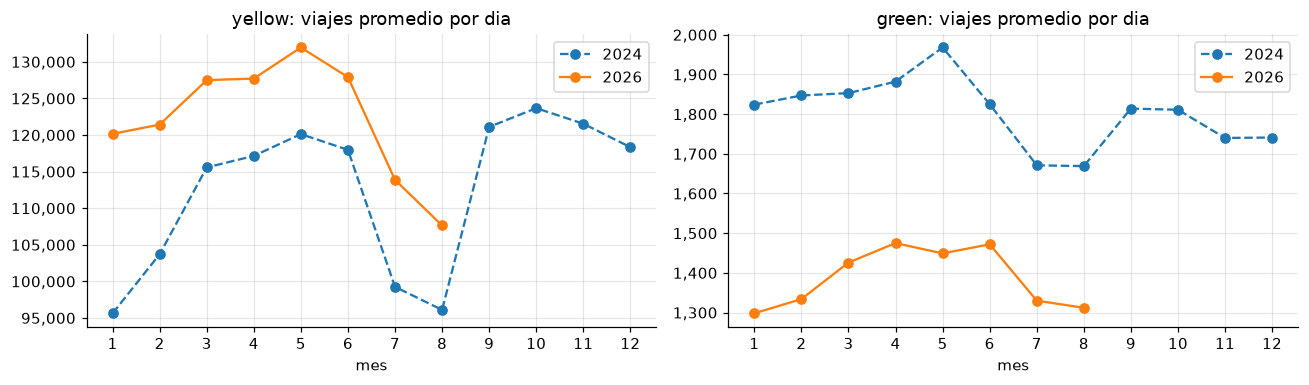

In [7]:
comparacion = q('''
WITH viajes AS (
    SELECT split_part(filename, '/', 3)                                        AS tipo,
           strptime(regexp_extract(filename, '(\d{4}-\d{2})\.parquet$', 1), '%Y-%m')::DATE AS mes_archivo,
           coalesce(tpep_pickup_datetime, lpep_pickup_datetime)                AS pickup
    FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
)
SELECT tipo, year(pickup) AS anio, month(pickup) AS mes,
       round(count(*) / count(DISTINCT pickup::DATE)) AS viajes_por_dia
FROM viajes
WHERE date_trunc('month', pickup) = mes_archivo
GROUP BY ALL
ORDER BY tipo DESC, anio, mes
''')
tabla = comparacion.pivot_table(index="mes", columns=["tipo", "anio"], values="viajes_por_dia")
for tipo in ["yellow", "green"]:
    tabla[(tipo, "cambio % 2024 a 2026")] = 100 * (tabla[(tipo, 2026)] / tabla[(tipo, 2024)] - 1)
display(tabla[["yellow", "green"]])

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    for anio, estilo in [(2024, "--"), (2026, "-")]:
        d = comparacion[(comparacion.tipo == tipo) & (comparacion.anio == anio)]
        eje.plot(d.mes, d.viajes_por_dia, estilo, marker="o", label=str(anio))
    eje.set_title(f"{tipo}: viajes promedio por dia")
    eje.set_xticks(range(1, 13))
    eje.set_xlabel("mes")
    eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    eje.legend()
plt.tight_layout()
plt.show()

## 5.7 Las consultas anteriores con el nuevo conjunto de archivos

### Columnas presentes en cada anio

In [8]:
q('''
WITH columnas AS (
    SELECT DISTINCT split_part(file_name, '/', 3) AS tipo,
                    split_part(file_name, '/', 4) AS anio,
                    name AS columna
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE name <> 'schema'
)
SELECT tipo, columna,
       bool_or(anio = '2024') AS en_2024,
       bool_or(anio = '2026') AS en_2026
FROM columnas
GROUP BY ALL
HAVING NOT (en_2024 AND en_2026)
ORDER BY tipo DESC, columna
''')

4 filas | 0.01 s


,tipo,columna,en_2024,en_2026
0,yellow,cbd_congestion_fee,False,True
1,yellow,request_source,False,True
2,green,cbd_congestion_fee,False,True
3,green,request_source,False,True


### Lectura sin union_by_name

In [9]:
print("Columnas al leer yellow sin union_by_name:")
columnas = con.sql("DESCRIBE SELECT * FROM read_parquet('data/raw/yellow/*/*.parquet')").df()
print(", ".join(columnas.column_name))
print()
try:
    con.sql('''
        SELECT avg(cbd_congestion_fee)
        FROM read_parquet('data/raw/yellow/*/*.parquet')
    ''').fetchall()
except duckdb.Error as error:
    print("Sin union_by_name ->", type(error).__name__, str(error).splitlines()[0])

q('''
SELECT split_part(filename, '/', 4) AS anio,
       count(*)                     AS registros,
       count(cbd_congestion_fee)    AS cbd_congestion_fee_no_nulo,
       round(avg(cbd_congestion_fee), 3) AS cbd_promedio
FROM read_parquet('data/raw/yellow/*/*.parquet', filename = true, union_by_name = true)
GROUP BY ALL
ORDER BY anio
''')

Columnas al leer yellow sin union_by_name:
VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee

Sin union_by_name -> BinderException Binder Error: Referenced column "cbd_congestion_fee" not found in FROM clause!


2 filas | 0.54 s


,anio,registros,cbd_congestion_fee_no_nulo,cbd_promedio
0,2024,41169720,0,NaN
1,2026,29703355,29703355,0.54


### Consultas del Ejercicio 3 sin cambios

In [10]:
from run_sql import cargar_consultas

CONSULTAS_EJ3 = cargar_consultas(Path("sql/03_exploracion_parquet.sql"))
for nombre in ["q01_cantidad_archivos", "q03_total_registros", "q12_fechas_fuera_de_periodo"]:
    descripcion, sql = CONSULTAS_EJ3[nombre]
    print(f"\n{nombre}: {descripcion}")
    display(q(sql))


q01_cantidad_archivos: 3.1 Cantidad de archivos Parquet disponibles, por tipo de taxi y anio.
4 filas | 0.01 s


,tipo,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,green,2026,8,2026-01,2026-08
2,yellow,2024,12,2024-01,2024-12
3,yellow,2026,8,2026-01,2026-08



q03_total_registros: 3.2 Total de registros por tipo leyendo los datos (valida el resultado de q02).


3 filas | 0.56 s


,tipo,registros
0,green,997332
1,yellow,70873075
2,TOTAL,71870407



q12_fechas_fuera_de_periodo: 3.6 Viajes cuya fecha de inicio no corresponde al mes del archivo.


2 filas | 0.94 s


,tipo,registros,fuera_del_mes,mas_de_un_mes_antes,despues_del_mes,pickup_minimo,pickup_maximo
0,yellow,70873075,566,65,194,2001-01-01 09:23:58,2026-08-31 23:59:59
1,green,997332,262,17,89,2008-12-31 00:00:00,2026-08-31 23:58:28


### Vistas del Ejercicio 4 sin cambios

In [11]:
con.sql(r'''
CREATE OR REPLACE VIEW viajes AS
SELECT
    split_part(filename, '/', 3)                                        AS tipo,
    strptime(regexp_extract(filename, '(\d{4}-\d{2})\.parquet$', 1), '%Y-%m')::DATE AS mes_archivo,
    VendorID                                                            AS vendor_id,
    coalesce(tpep_pickup_datetime,  lpep_pickup_datetime)               AS pickup,
    coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)              AS dropoff,
    date_diff('second', coalesce(tpep_pickup_datetime,  lpep_pickup_datetime),
                        coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0 AS duracion_min,
    passenger_count, trip_distance,
    RatecodeID AS ratecode_id, PULocationID AS pu_zona, DOLocationID AS do_zona,
    payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount,
    improvement_surcharge, congestion_surcharge, cbd_congestion_fee,
    Airport_fee AS airport_fee, total_amount, trip_type
FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
''')
con.sql('''
CREATE OR REPLACE VIEW viajes_limpios AS
SELECT *
FROM viajes
WHERE date_trunc('month', pickup) = mes_archivo
  AND duracion_min BETWEEN 1 AND 180
  AND trip_distance > 0 AND trip_distance <= 100
  AND fare_amount >= 0 AND total_amount >= 0 AND tip_amount >= 0
''')

q('''
SELECT anio, tipo,
       v.registros,
       l.registros                                   AS registros_limpios,
       round(100.0 * l.registros / v.registros, 2)  AS pct_conservado
FROM (SELECT year(mes_archivo) AS anio, tipo, count(*) AS registros FROM viajes GROUP BY ALL) v
JOIN (SELECT year(mes_archivo) AS anio, tipo, count(*) AS registros FROM viajes_limpios GROUP BY ALL) l
  USING (anio, tipo)
ORDER BY anio, tipo DESC
''')

4 filas | 2.13 s


,anio,tipo,registros,registros_limpios,pct_conservado
0,2024,yellow,41169720,39562556,96.10
1,2024,green,660218,614284,93.04
2,2026,yellow,29703355,28145839,94.76
3,2026,green,337114,319435,94.76


### Una consulta del Ejercicio 4 con y sin separar por anio

In [12]:
sin_anio = q('''
SELECT tipo,
       round(median(trip_distance), 2)                                  AS distancia_mediana,
       round(median(total_amount), 2)                                   AS total_mediano,
       round(100.0 * avg((cbd_congestion_fee > 0)::INT), 1)             AS pct_con_cargo_cbd,
       round(100.0 * avg((coalesce(cbd_congestion_fee, 0) > 0)::INT), 1) AS pct_con_cargo_cbd_todos
FROM viajes_limpios
GROUP BY tipo
ORDER BY tipo DESC
''')
display(sin_anio)

con_anio = q('''
SELECT year(pickup) AS anio, tipo,
       round(median(trip_distance), 2)                                  AS distancia_mediana,
       round(median(total_amount), 2)                                   AS total_mediano,
       round(100.0 * avg((coalesce(cbd_congestion_fee, 0) > 0)::INT), 1) AS pct_con_cargo_cbd
FROM viajes_limpios
GROUP BY ALL
ORDER BY tipo DESC, anio
''')
display(con_anio)

2 filas | 3.67 s


,tipo,distancia_mediana,total_mediano,pct_con_cargo_cbd,pct_con_cargo_cbd_todos
0,yellow,1.85,22.20,72.50,30.10
1,green,2.04,19.68,8.60,2.90


4 filas | 3.41 s


,anio,tipo,distancia_mediana,total_mediano,pct_con_cargo_cbd
0,2024,yellow,1.80,21.20,0.00
1,2026,yellow,1.94,23.58,72.50
2,2024,green,1.98,19.26,0.00
3,2026,green,2.17,20.52,8.60


## Respuestas

5.1 ¿Que se modifico en el sistema de descarga?

Desde el Ejercicio 2 el script ya recibia los anios como parametro, asi que no hubo que tocar la logica de descarga. El unico cambio fue agregar 2024 a la lista de anios por defecto, que ahora es 2024 y 2026. Con esto, el comando de siempre baja los dos anios y el archivo manifest.csv queda con el estado de ambos. Si se hubiera usado solo la opcion para pedir 2024, el manifiesto se habria reescrito unicamente con 2024 y se perderia el registro de 2026.

5.2 y 5.3 ¿Se conservaron los archivos de 2026 y se evito descargarlos de nuevo?

Si. En la primera corrida con 2024 se bajaron los 24 archivos nuevos y los 16 de 2026 aparecieron como ya existentes y completos, asi que no se volvieron a bajar. La celda de la seccion 5.2 a 5.4 corre el script otra vez y muestra que ahora no se descarga nada, porque los 40 archivos ya estan. El script decide si un archivo esta completo comparando su tamanio con el del servidor y revisando que sea un Parquet valido.

5.4 y 5.5 ¿Se incorporaron bien los archivos nuevos?

Si. Hay 12 archivos amarillos y 12 verdes de 2024, de enero a diciembre, y cada uno tiene el mismo tamanio que en el servidor. Los archivos de 2024 suman 41,169,720 viajes amarillos y 660,218 verdes. En total el conjunto tiene ahora 40 archivos y 71,870,407 registros.

5.6 ¿Se pueden consultar 2024 y 2026 juntos?

Si, con la misma ruta de siempre, data/raw/*/*/*.parquet, DuckDB lee los dos anios a la vez y la ruta del archivo dice a que anio y tipo pertenece cada viaje. Al comparar los mismos meses se ve que en 2026 hay entre 8 % y 26 % mas viajes amarillos por dia que en 2024, mientras que los verdes bajaron entre 19 % y 29 %. Los dos anios siguen el mismo patron, con mas viajes en primavera y menos en verano.

5.7 ¿Hay que cambiar las consultas anteriores?

No hubo que cambiar ninguna para que funcionaran. Las consultas del Ejercicio 3 y las vistas del Ejercicio 4 se corrieron tal cual y ya incluyen 2024. Esto funciona porque desde el principio se uso la opcion union_by_name. Sin ella, DuckDB toma las columnas del primer archivo, que ahora es de 2024 y no tiene la columna cbd_congestion_fee, y cualquier consulta que la use falla. La prueba de la seccion 5.7 lo muestra.

Lo que si cambia es el significado de algunos resultados. Si una consulta no separa por anio, mezcla 2024 con 2026 sin avisar. La ultima prueba de la seccion 5.7 lo muestra con el cargo por entrar al sur de Manhattan, que no existia en 2024. La consulta del Ejercicio 4 sigue diciendo que el 72.5 % de los viajes amarillos paga ese cargo, como si nada hubiera cambiado, porque los valores vacios de 2024 simplemente no se cuentan. Si esos vacios se cuentan como cero, el resultado baja a 30.1 %. Ninguno de los dos numeros sirve si se mezclan los anios. Por eso, a partir de ahora las consultas deben agrupar por anio o filtrar el anio que se quiere estudiar, y hay que decidir en cada caso si una columna que no existia cuenta como cero o como dato faltante.

La regla de limpieza que compara el mes del viaje con el mes del archivo sigue sirviendo. En 2024 tambien hay fechas absurdas, como un viaje de 2002 y otro con fecha de junio de 2026 dentro de un archivo de 2024, y esa regla los deja fuera.

5.8 ¿Que consultas se usaron para validar 2024?

Se uso la lectura del manifiesto para revisar el estado y el tamanio de cada archivo, y los metadatos de los Parquet para contar archivos, meses y registros por anio. Tambien se conto todo con read_parquet para confirmar el total. Ademas se compararon los viajes por dia de cada mes entre 2024 y 2026, se revisaron las columnas que solo existen en un anio y se volvieron a correr consultas de los ejercicios 3 y 4. Todas estan en las celdas de este notebook.

5.9 ¿Que permite agregar archivos nuevos sin cambiar todo el analisis?

Lo permiten varias cosas del diseno. Los archivos se guardan siempre como data/raw/tipo/anio/archivo, asi que un anio nuevo es solo una carpeta mas, y las consultas leen con un comodin que la incluye sola. El tipo, el anio y el mes se sacan de la ruta del archivo, sin agregar columnas a mano. La opcion union_by_name une columnas por nombre aunque cambien entre anios. El script de descarga recibe los anios como parametro, no repite archivos que ya estan completos y registra todo en el manifiesto. Por ultimo, las consultas leen los Parquet directamente, por lo que no hay ninguna tabla que haya que volver a cargar.